## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading The Dataset

In [2]:
grocery_df = pd.read_excel('project_data_BDM.xlsx', sheet_name='Cleaned_Data')
grocery_df.shape

(365, 19)

## Overview

In [3]:
grocery_df.head()

,Date,Rice (Local),Rice (Premium),Wheat Flour,Flattened Rice,Puffed Rice,Pulses,Cooking Oils,Coconut Oil,Sugar,Salt,Spices,Snacks,Tea,Dairy Product,Potatoes & Onions,Toiletries,Soft Drinks,Egg
0,2024-06-01,11,11,5,3,3,9,3,1,6,2,2,4,6,2,9,1,5,10
1,2024-06-02,9,14,10,1,1,11,4,7,4,3,1,6,4,3,8,2,6,14
2,2024-06-03,11,15,6,2,5,9,2,6,3,1,2,8,3,5,10,3,6,9
3,2024-06-04,10,17,5,3,4,11,3,1,4,1,2,10,4,5,9,1,7,14
4,2024-06-05,9,8,8,1,3,9,4,0,1,2,1,7,4,5,10,3,8,7


In [4]:
grocery_df.columns

Index(['Date', 'Rice (Local)', 'Rice (Premium)', 'Wheat Flour',
       'Flattened Rice', 'Puffed Rice', 'Pulses', 'Cooking Oils',
       'Coconut Oil', 'Sugar', 'Salt', 'Spices', 'Snacks', 'Tea',
       'Dairy Product', 'Potatoes & Onions', 'Toiletries', 'Soft Drinks',
       'Egg'],
      dtype='object')

In [5]:
grocery_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               365 non-null    datetime64[ns]
 1   Rice (Local)       365 non-null    int64         
 2   Rice (Premium)     365 non-null    int64         
 3   Wheat Flour        365 non-null    int64         
 4   Flattened Rice     365 non-null    int64         
 5   Puffed Rice        365 non-null    int64         
 6   Pulses             365 non-null    int64         
 7   Cooking Oils       365 non-null    int64         
 8   Coconut Oil        365 non-null    int64         
 9   Sugar              365 non-null    int64         
 10  Salt               365 non-null    int64         
 11  Spices             365 non-null    int64         
 12  Snacks             365 non-null    int64         
 13  Tea                365 non-null    int64         
 14  Dairy Prod

## Descriptive Statistics

In [6]:
sku_data = grocery_df.drop(columns=['Date'])
desc_stats = sku_data.describe().T
print(desc_stats)

                   count       mean       std  min   25%   50%   75%   max
Rice (Local)       365.0  14.517808  4.465722  2.0  11.0  16.0  18.0  23.0
Rice (Premium)     365.0   9.268493  7.445717  0.0   4.0   8.0  13.0  39.0
Wheat Flour        365.0   8.260274  2.415764  1.0   7.0   9.0  10.0  14.0
Flattened Rice     365.0   4.090411  1.372829  1.0   3.0   4.0   5.0   8.0
Puffed Rice        365.0   5.328767  1.974110  0.0   4.0   6.0   7.0  10.0
Pulses             365.0  13.235616  4.489835  1.0  10.0  14.0  16.0  34.0
Cooking Oils       365.0   5.161644  2.818436  0.0   4.0   5.0   6.0  27.0
Coconut Oil        365.0   2.035616  1.703694  0.0   1.0   2.0   3.0   8.0
Sugar              365.0   5.797260  1.697604  1.0   5.0   6.0   7.0  10.0
Salt               365.0   3.887671  1.644500  0.0   3.0   4.0   5.0   9.0
Spices             365.0   4.082192  2.518903  0.0   2.0   4.0   5.0  22.0
Snacks             365.0   8.167123  3.234772  1.0   6.0   8.0  10.0  29.0
Tea                365.0 

In [7]:
desc_stats['median'] = sku_data.median()
desc_stats['mode'] = sku_data.mode().iloc[0]
desc_stats['std. deviation'] = sku_data.std()
desc_stats['variance'] = sku_data.var()
desc_stats['skew'] = sku_data.skew()
desc_stats['kurtosis'] = sku_data.kurtosis()
desc_stats

,count,mean,std,min,25%,50%,75%,max,median,mode,std. deviation,variance,skew,kurtosis
Rice (Local),365.0,14.517808,4.465722,2.0,11.0,16.0,18.0,23.0,16.0,17,4.465722,19.942677,-0.676192,-0.085767
Rice (Premium),365.0,9.268493,7.445717,0.0,4.0,8.0,13.0,39.0,8.0,0,7.445717,55.438702,0.916292,0.823397
Wheat Flour,365.0,8.260274,2.415764,1.0,7.0,9.0,10.0,14.0,9.0,9,2.415764,5.835918,-0.636825,0.363190
Flattened Rice,365.0,4.090411,1.372829,1.0,3.0,4.0,5.0,8.0,4.0,4,1.372829,1.884661,-0.112468,-0.045240
Puffed Rice,365.0,5.328767,1.974110,0.0,4.0,6.0,7.0,10.0,6.0,6,1.974110,3.897110,-0.395001,-0.025826
Pulses,365.0,13.235616,4.489835,1.0,10.0,14.0,16.0,34.0,14.0,15,4.489835,20.158618,0.744599,3.282754
Cooking Oils,365.0,5.161644,2.818436,0.0,4.0,5.0,6.0,27.0,5.0,5,2.818436,7.943580,3.004818,17.350979
Coconut Oil,365.0,2.035616,1.703694,0.0,1.0,2.0,3.0,8.0,2.0,1,1.703694,2.902574,0.768702,-0.029099
Sugar,365.0,5.797260,1.697604,1.0,5.0,6.0,7.0,10.0,6.0,6,1.697604,2.881861,-0.286240,-0.160527
Salt,365.0,3.887671,1.644500,0.0,3.0,4.0,5.0,9.0,4.0,5,1.644500,2.704381,-0.236499,-0.211479


## Mid Term Visualization

In [8]:
# Make a copy of dataset to keep original one intact
df_copy = grocery_df.copy(deep=True)
# Add Month-Year column
df_copy['Month'] = df_copy['Date'].dt.strftime('%b %Y')
df_copy.columns

Index(['Date', 'Rice (Local)', 'Rice (Premium)', 'Wheat Flour',
       'Flattened Rice', 'Puffed Rice', 'Pulses', 'Cooking Oils',
       'Coconut Oil', 'Sugar', 'Salt', 'Spices', 'Snacks', 'Tea',
       'Dairy Product', 'Potatoes & Onions', 'Toiletries', 'Soft Drinks',
       'Egg', 'Month'],
      dtype='object')

### Monthly Trend Analysis

In [9]:
# Adding a Category column to categorize the products
grains_staples = ['Rice (Local)', 'Rice (Premium)', 'Wheat Flour', 'Flattened Rice', 'Puffed Rice']
cooking_essentials = ['Pulses', 'Cooking Oils', 'Coconut Oil', 'Sugar', 'Salt', 'Spices']
sancks_beverages = ['Snacks', 'Tea', 'Soft Drinks']
perishable_others = ['Dairy Product', 'Potatoes & Onions', 'Toiletries', 'Egg']

# Function to apply to get Category column
def categorizing(product):
    if product in grains_staples:
        return "Grains & Staples"
    elif product in cooking_essentials:
        return "Cooking Essentials"
    elif product in sancks_beverages:
        return "Snacks & Beverages"
    else:
        return "Perishable & Others"


In [10]:
# Convert the dataframe in long format to plot trend
df_melted = df_copy.melt(id_vars=['Date','Month'],
                         value_vars=sku_data.columns,
                         var_name='SKU',
                         value_name='Sales')
df_melted['Category'] = df_melted['SKU'].apply(categorizing)
monthly_trend = df_melted.groupby(['Month','Category'])['Sales'].sum().reset_index()
df_melted.head()

,Date,Month,SKU,Sales,Category
0,2024-06-01,Jun 2024,Rice (Local),11,Grains & Staples
1,2024-06-02,Jun 2024,Rice (Local),9,Grains & Staples
2,2024-06-03,Jun 2024,Rice (Local),11,Grains & Staples
3,2024-06-04,Jun 2024,Rice (Local),10,Grains & Staples
4,2024-06-05,Jun 2024,Rice (Local),9,Grains & Staples


In [11]:
monthly_trend.head()

,Month,Category,Sales
0,Apr 2025,Cooking Essentials,1024
1,Apr 2025,Grains & Staples,1360
2,Apr 2025,Perishable & Others,941
3,Apr 2025,Snacks & Beverages,856
4,Aug 2024,Cooking Essentials,696


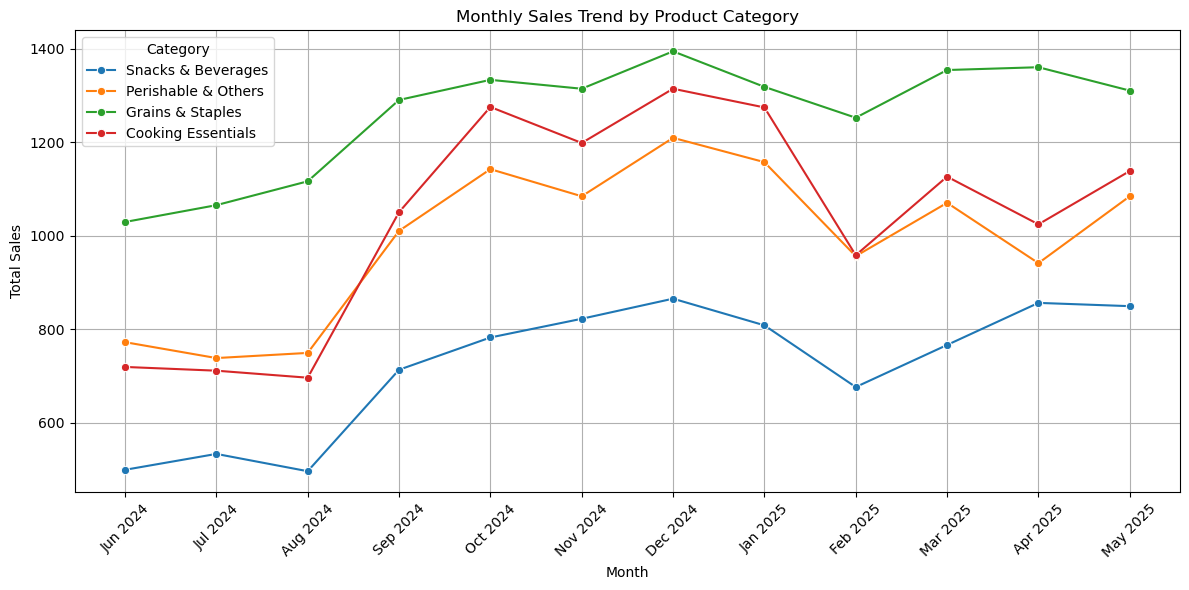

In [12]:
# Convert to datetime for sorting
monthly_trend['Month'] = pd.to_datetime(monthly_trend['Month'], format='%b %Y')

# Sort the DataFrame by Month
monthly_trend = monthly_trend.sort_values('Month')

# Format Month as "Jul 2024"
monthly_trend['Month'] = monthly_trend['Month'].dt.strftime('%b %Y')

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trend, x='Month', y='Sales', hue='Category', marker='o')
plt.title("Monthly Sales Trend by Product Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("monthly_sales_trend.png", dpi=300)
plt.show()

### Bar Plot

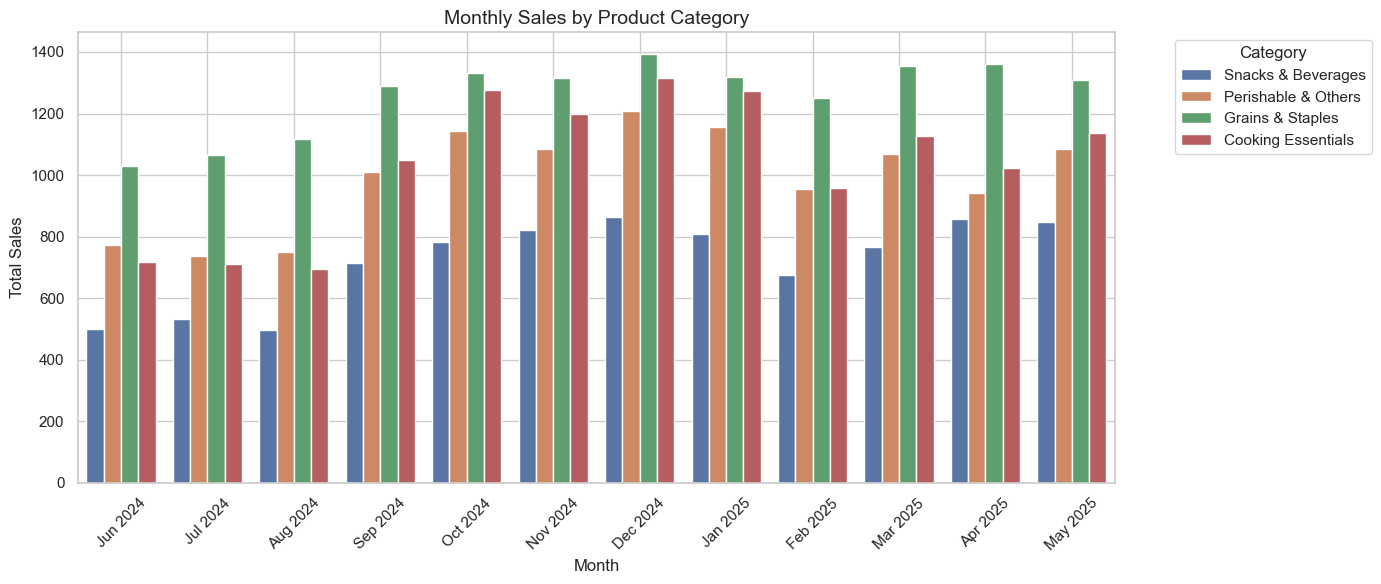

In [13]:
# Set style
sns.set(style="whitegrid")

# Create bar plot
plt.figure(figsize=(14, 6))
sns.barplot(
    data=monthly_trend,
    x='Month',
    y='Sales',
    hue='Category'
)
plt.title("Monthly Sales by Product Category", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.savefig("monthly_sales_barplot.png", dpi=300)
plt.show()

### Box Plot

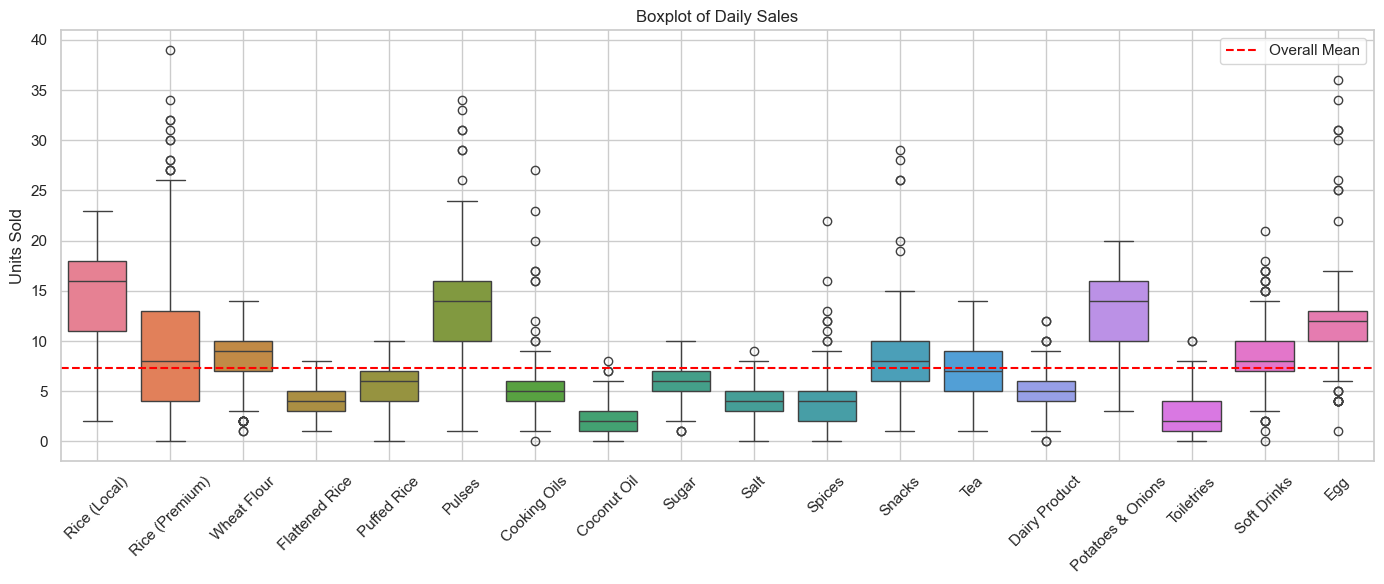

In [14]:
# Box plot of 18 SKUs
plt.figure(figsize=(14, 6))
sns.boxplot(data=sku_data)
plt.title("Boxplot of Daily Sales")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.axhline(sku_data.mean().mean(), linestyle='--', color='red', label='Overall Mean')
plt.legend()
plt.tight_layout()
plt.savefig('boxplot_all_products', dpi=300)
plt.show()

### Weekday vs Weekend average sales over different SKUs

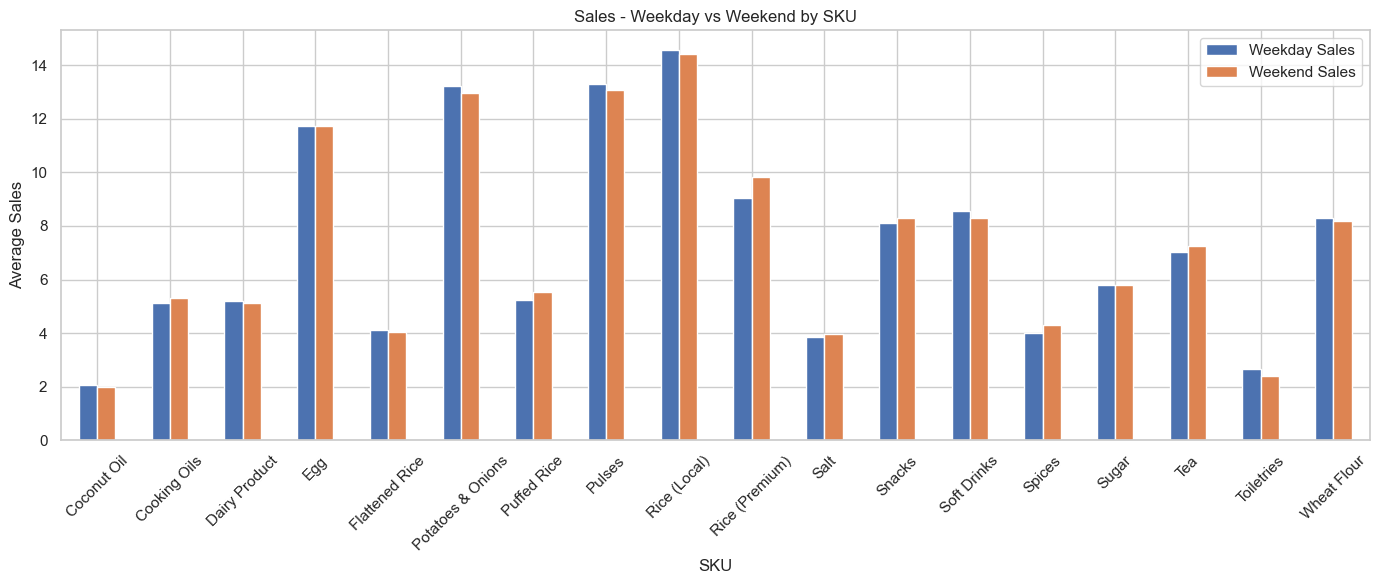

In [15]:
# Convert from wide to long format
df_melted['DayType'] = df_melted['Date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
# Group by SKU and IsWeekday to get total sales
grouped = df_melted.groupby(['SKU', 'DayType'])['Sales'].mean().reset_index()

# Pivot the table to get Weekday vs Weekend in columns
pivot = grouped.pivot(index='SKU', columns='DayType', values='Sales').fillna(0)

# Rename columns to make it clearer
pivot.columns.name = None
pivot = pivot.rename(columns={'Weekday': 'Weekday Sales', 'Weekend': 'Weekend Sales'})

# Plotting
pivot.plot(kind='bar', figsize=(14, 6))
plt.title('Sales - Weekday vs Weekend by SKU')
plt.ylabel('Average Sales')
plt.xlabel('SKU')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Final Submission

In [16]:
df = grocery_df.copy(deep=True)  # Copying dataframe to keep original one intact

# Data of all 18 SKUs
products_data = df.drop(columns=['Date'])

# Ensure that date columns is in padnas datetime object
df['Date'] = pd.to_datetime(df['Date'])
type(df.Date[0])

pandas._libs.tslibs.timestamps.Timestamp

### Rolling Average

In [17]:
# Set date as index for ploting
df.set_index('Date', inplace=True)

# Identify top 5 products based on total annual sales
top_products = df.sum().sort_values(ascending=False).head(5).index.tolist()

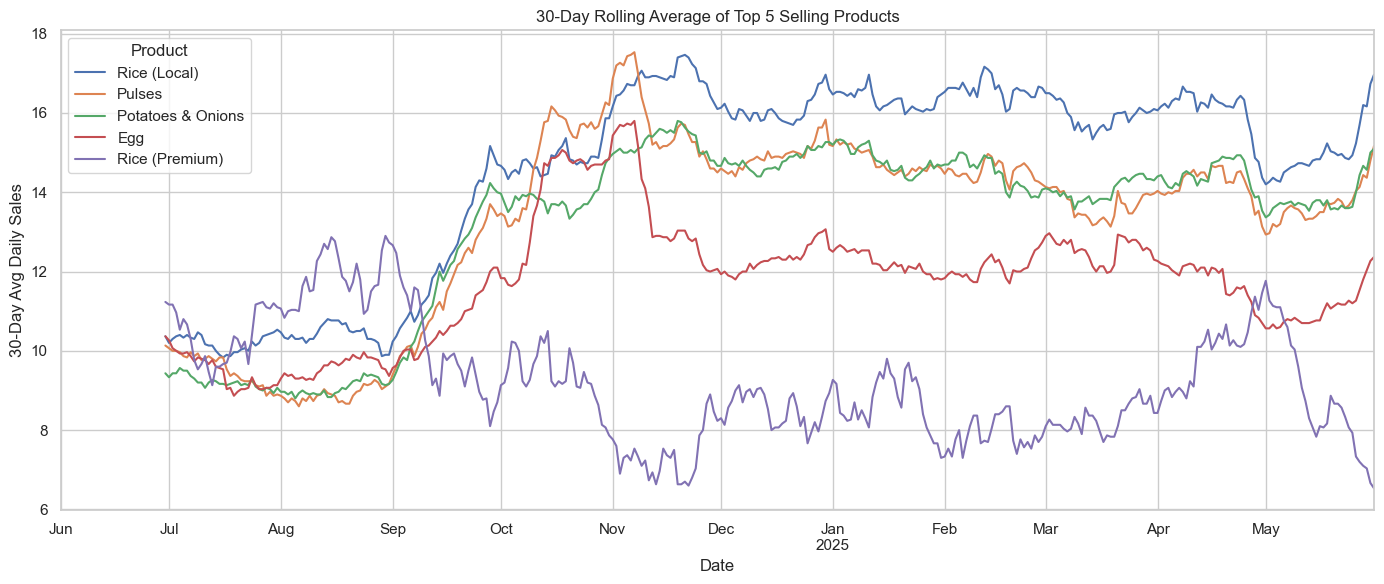

In [18]:
# Plot rolling averages for 30 days. During the analysis (go to Mid Term Vizualization => Weekday vs Weekend) there is no weekend spikes.
# That's why take 30-days rolling average to smooth the demand.
plt.figure(figsize=(14, 6))
for product in top_products:
    df[product].rolling(window=30).mean().plot(label=product)

plt.title("30-Day Rolling Average of Top 5 Selling Products")
plt.xlabel("Date")
plt.ylabel("30-Day Avg Daily Sales")
plt.legend(title="Product")
plt.tight_layout()
plt.grid(True)
plt.show()

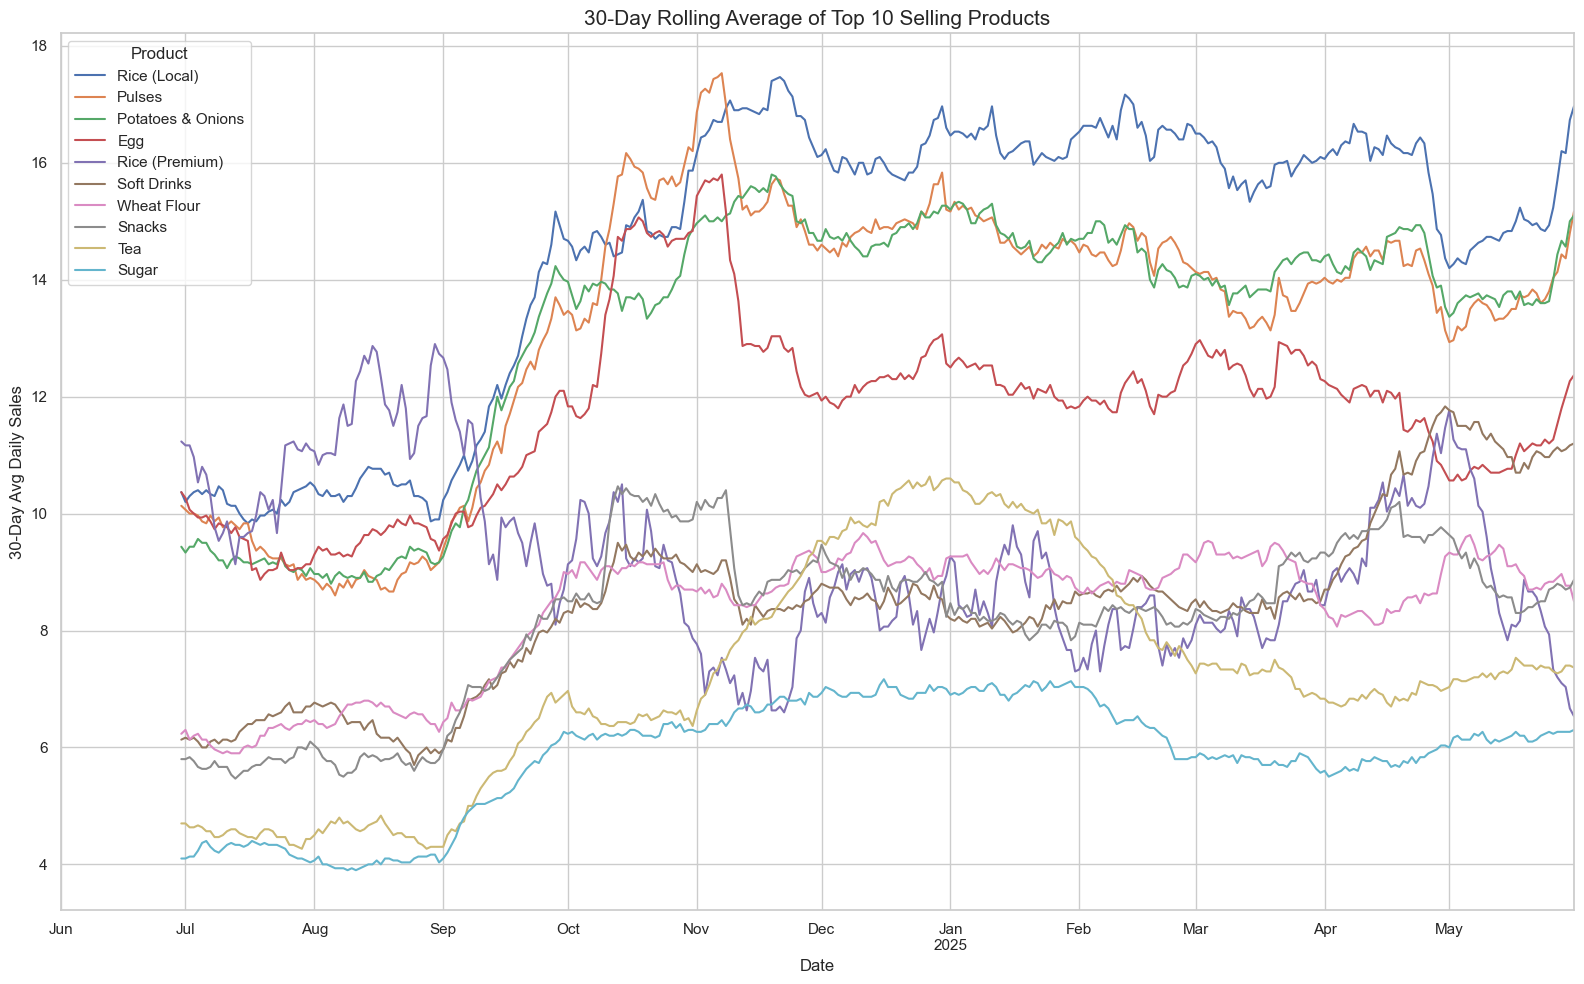

In [19]:
# Doing the same thing but now for taking top 10 instead of 5 
sorted_products = df.sum().sort_values(ascending=False).head(10).index.to_list()
plt.figure(figsize=(16,10))
for product in sorted_products:
    df[product].rolling(window=30).mean().plot(label=product)

plt.title("30-Day Rolling Average of Top 10 Selling Products",fontsize=15)
plt.xlabel("Date")
plt.ylabel("30-Day Avg Daily Sales")
plt.legend(title="Product")
plt.tight_layout()
plt.grid(True)
plt.savefig('30day_rolling_average_top10selling.png',dpi=300)
plt.show()

### Demand Variation Index

In [20]:
# Calculating the means of products
means = products_data.mean().round(2)

# Calculating standard deviations of products
std_devs = products_data.std()

# Calculate DVI (%) using formula DVI = (std_dev/mean) * 100
perc_dvi = (std_devs/means)*100

# Creating a DVI dataframe
df_dvi = pd.DataFrame({
    'Means' : means,
    'Std_Dev' : std_devs,
    'DVI (%)' : perc_dvi.round(2)
})

# showing DVI table in descending order of percentage DVI
df_dvi = df_dvi.sort_values(by='DVI (%)', ascending=False)
df_dvi.head()


,Means,Std_Dev,DVI (%)
Coconut Oil,2.04,1.703694,83.51
Rice (Premium),9.27,7.445717,80.32
Toiletries,2.59,1.978022,76.37
Spices,4.08,2.518903,61.74
Cooking Oils,5.16,2.818436,54.62


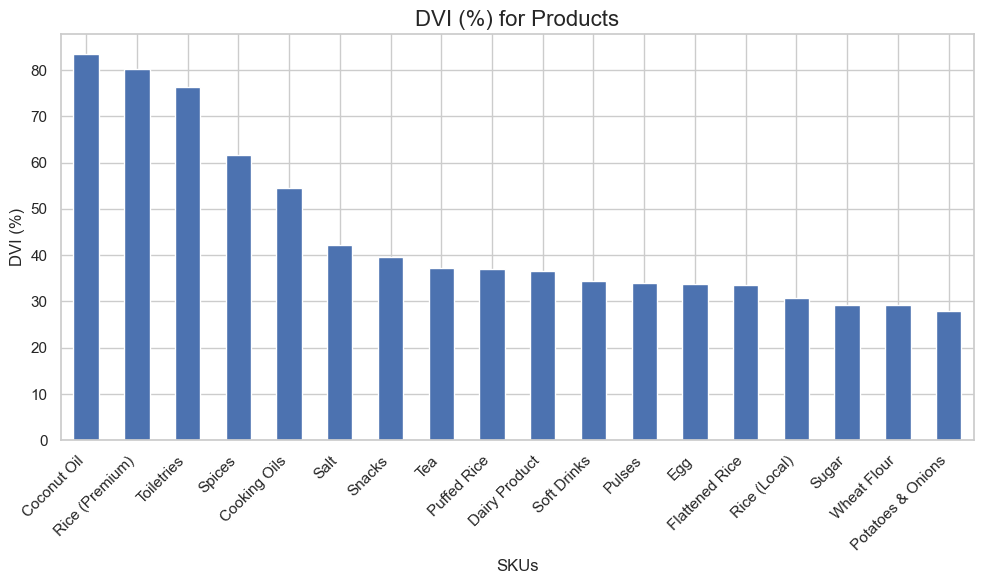

In [28]:
# Plotting DVI percentages as a bar chart
plt.figure(figsize=(10, 6))
df_dvi['DVI (%)'].plot(kind='bar')
plt.title('DVI (%) for Products', fontsize=16)
plt.xlabel('SKUs')
plt.ylabel('DVI (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('percentage_dvi.png',dpi=400)
plt.show()

### Festival Demand Analysis

In [22]:
import pandas as pd

# Load the cleaned data
df2 = grocery_df.copy(deep=True)

# Ensure date column is in datetime format
df2['Date'] = pd.to_datetime(df2['Date'])

# Define festival windows from June 2024 to May 2025 and add surplus day to define pre-festival shopping
festival_periods = [
    ('2024-10-06', '2024-10-13'),  # Durga Puja
    ('2024-10-28', '2024-10-31'),  # Kali Puja
    ('2025-03-25', '2025-03-29'),  # Shab-e-barat
    ('2025-03-27', '2025-03-30'),  # Eid
]
# Products' name
prod_name = products_data.columns

# Create a binary 'Festival' column. 1 for festival and 0 for non-festival days.
df2['Festival'] = 0
for start, end in festival_periods:
    condition = (df2['Date'] >= pd.to_datetime(start)) & (df2['Date'] <= pd.to_datetime(end))
    df2.loc[condition, 'Festival'] = 1

# Compute average sales during festival vs non-festival
festival_avg = df2[df2['Festival'] == 1][prod_name].mean().rename('Festival Avg')
non_festival_avg = df2[df2['Festival'] == 0][prod_name].mean().rename('Non-Festival Avg')

# Rounding off for Better Interpretation
festival_avg = np.round(festival_avg,2)
non_festival_avg = np.round(non_festival_avg,2)

# Combine into a comparison DataFrame and compute increased sales in percentage
comparison_df = pd.concat([festival_avg, non_festival_avg], axis=1)
comparison_df['% Increase'] = ((comparison_df['Festival Avg'] - comparison_df['Non-Festival Avg']) / comparison_df['Non-Festival Avg'] * 100).round(2)


In [23]:
# Display comparison
top_10 = comparison_df.sort_values(by='% Increase',ascending=False).head(10)
top_10

,Festival Avg,Non-Festival Avg,% Increase
Cooking Oils,9.44,4.94,91.09
Spices,5.94,3.99,48.87
Egg,16.94,11.46,47.82
Pulses,18.72,12.95,44.56
Snacks,11.11,8.01,38.70
Rice (Local),17.06,14.39,18.55
Potatoes & Onions,15.39,13.03,18.11
Puffed Rice,6.00,5.29,13.42
Soft Drinks,9.44,8.43,11.98
Salt,4.28,3.87,10.59


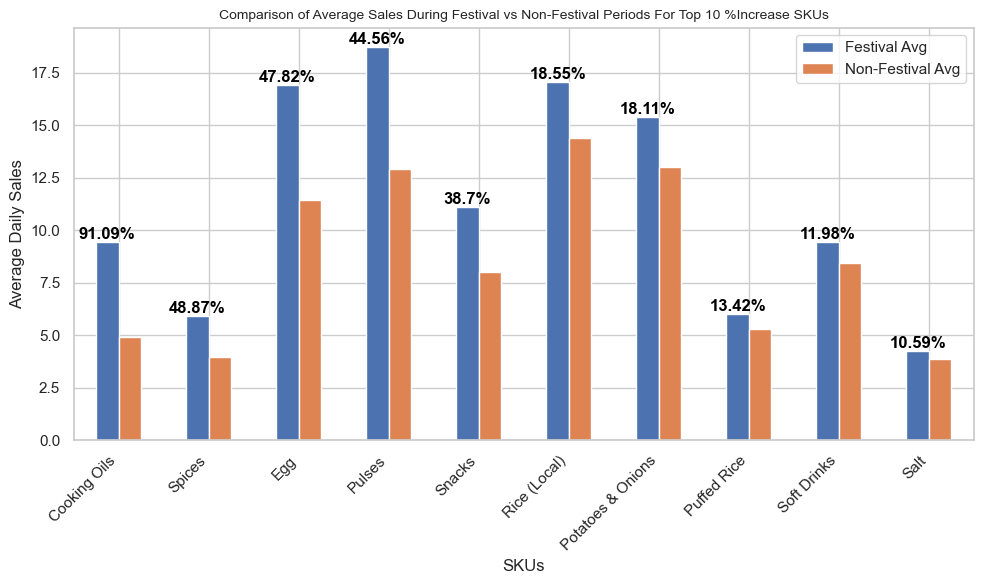

In [24]:
import matplotlib.pyplot as plt

# Plotting the bar chart for top 10 sales increase
ax = top_10[['Festival Avg', 'Non-Festival Avg']].plot(kind='bar', figsize=(10,6))

# Adding percentage labels on top of the Festival Avg bars
for i, p in enumerate(ax.patches[:len(top_10)]):  # Only loop over the Festival Avg bars
    # Get the height of the bar (value)
    height = p.get_height()

    # Add text with the percentage increase
    percentage = top_10['% Increase'].iloc[i]  # Get the % Increase for the Festival Avg
    ax.text(p.get_x() + p.get_width() / 2, p.get_height(), f'{percentage}%',
            ha='center', va='bottom', color='black', fontweight='bold')

# Title and labels
plt.title('Comparison of Average Sales During Festival vs Non-Festival Periods For Top 10 %Increase SKUs',fontsize=10)
plt.xlabel('SKUs')
plt.ylabel('Average Daily Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.savefig('festival_sale_increase.png',dpi=300)
plt.show()

### ABC Analysis

In [34]:
# Totals of all 18 products in descending order
product_totals = products_data.sum().sort_values(ascending=False)
# Creating a dataframe to store abc analysis
abc_df = pd.DataFrame({
    "Products":product_totals.index,
    "Annual Sale":product_totals.values
})

# Cumulative sum and cumulative percentage
abc_df['Cumulative Sum'] = abc_df['Annual Sale'].cumsum()
abc_df['Cumulative Percentage'] = np.round(abc_df['Cumulative Sum']*100/abc_df['Annual Sale'].sum(),2)

# Categorization
def categorize(percentage):
    if percentage <= 70:
        return "A"
    elif percentage <=90:
        return "B"
    else:
        return "C"
abc_df['Category'] = abc_df['Cumulative Percentage'].apply(categorize)

abc_df.sample(5)

,Products,Annual Sale,Cumulative Sum,Cumulative Percentage,Category
17,Coconut Oil,743,48195,100.00,C
15,Salt,1419,46506,96.50,C
9,Sugar,2116,36386,75.50,B
0,Rice (Local),5299,5299,10.99,A
4,Rice (Premium),3383,22590,46.87,A


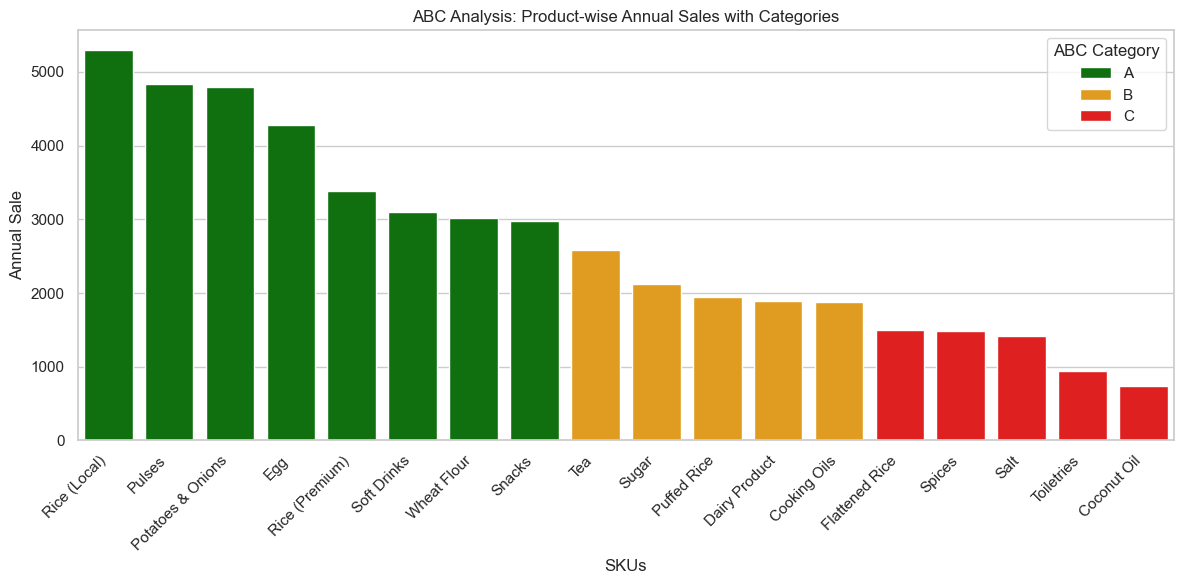

In [36]:
# Color palette for ABC
palette = {"A": "green", "B": "orange", "C": "red"}

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=abc_df,
    x="Products",
    y="Annual Sale",
    hue="Category",
    dodge=False,
    palette=palette
)

plt.title("ABC Analysis: Product-wise Annual Sales with Categories")
plt.xlabel("SKUs")
plt.ylabel("Annual Sale")
plt.xticks(rotation=45, ha='right')
plt.legend(title="ABC Category")
plt.tight_layout()
plt.savefig('abc_classification.png',dpi=300)
plt.show()


### Correlation Analysis

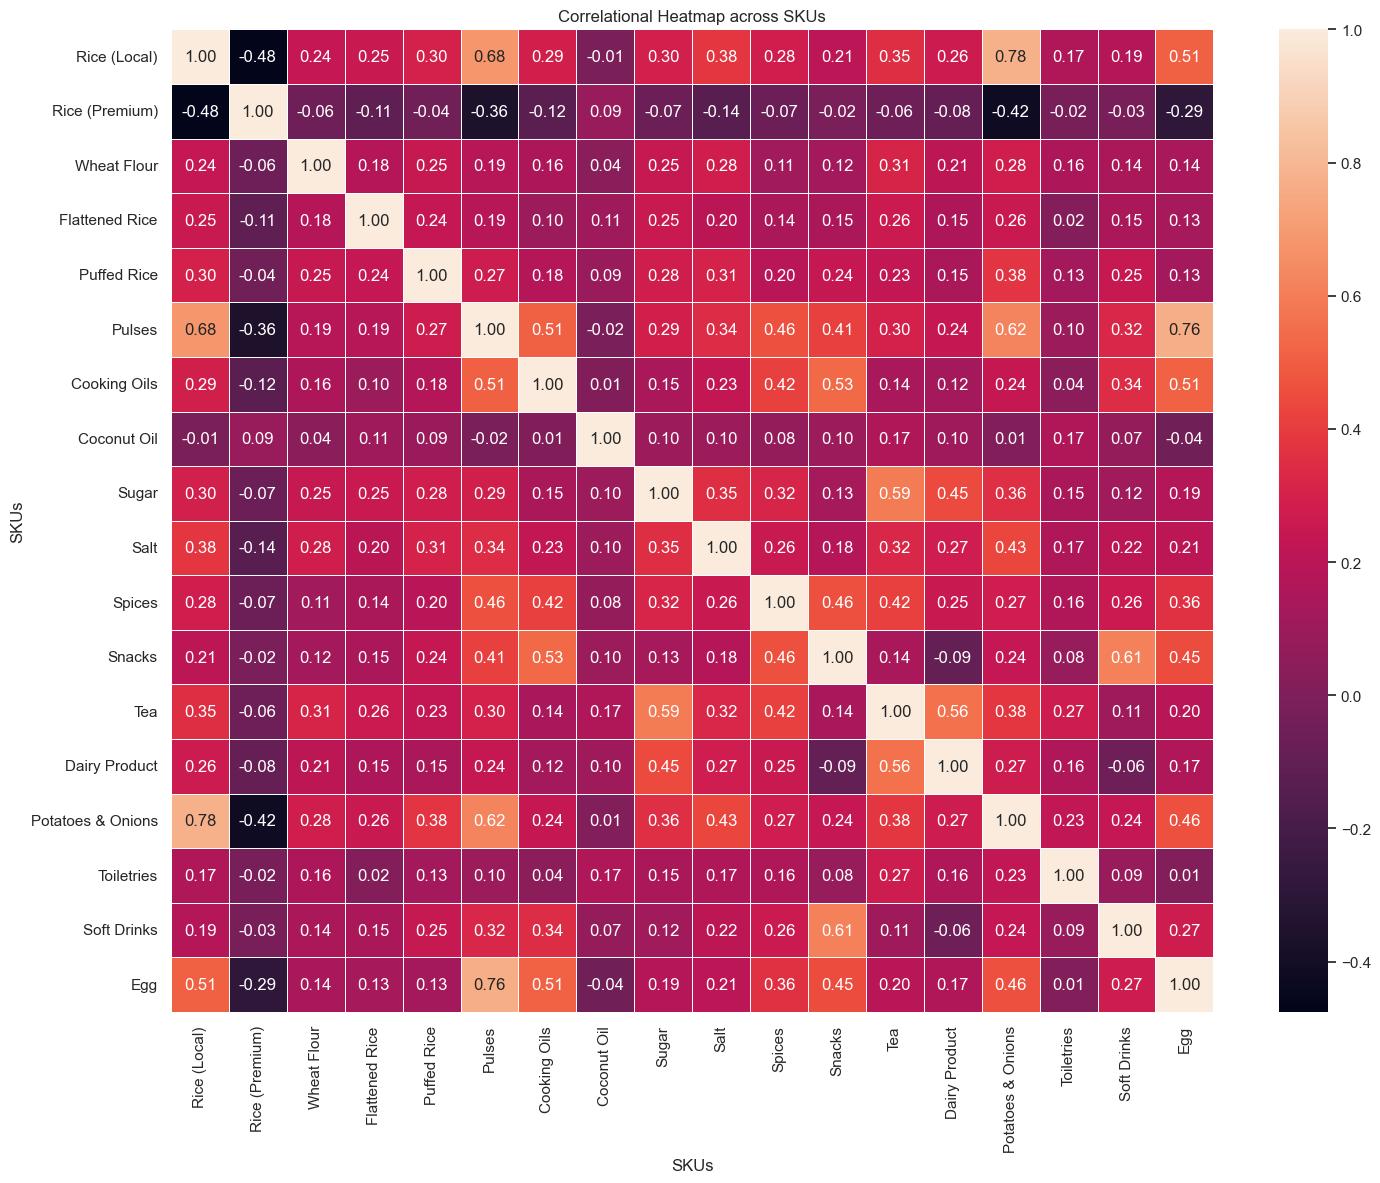

In [27]:
# Computing Pearson correlation across the 18 SKUs
corr_mat = products_data.corr()

# Plotting the correlational heatmap
plt.figure(figsize=(15,12))
sns.heatmap(corr_mat, linewidth=.5, annot=True, fmt='.2f')
plt.title('Correlational Heatmap across SKUs')
plt.xlabel('SKUs')
plt.ylabel('SKUs')
plt.tight_layout()
plt.savefig('corr_heatmap.png',dpi=400)
plt.show()

In [1]:
import pandas as pd

In [2]:
data = pd.read_excel('project_data_BDM.xlsx', sheet_name='Cleaned_Data')

In [3]:
data.shape

(365, 19)

In [4]:
data.head()

,Date,Rice (Local),Rice (Premium),Wheat Flour,Flattened Rice,Puffed Rice,Pulses,Cooking Oils,Coconut Oil,Sugar,Salt,Spices,Snacks,Tea,Dairy Product,Potatoes & Onions,Toiletries,Soft Drinks,Egg
0,2024-06-01,11,11,5,3,3,9,3,1,6,2,2,4,6,2,9,1,5,10
1,2024-06-02,9,14,10,1,1,11,4,7,4,3,1,6,4,3,8,2,6,14
2,2024-06-03,11,15,6,2,5,9,2,6,3,1,2,8,3,5,10,3,6,9
3,2024-06-04,10,17,5,3,4,11,3,1,4,1,2,10,4,5,9,1,7,14
4,2024-06-05,9,8,8,1,3,9,4,0,1,2,1,7,4,5,10,3,8,7


In [15]:
data['Date'] = pd.to_datetime(data['Date'])
data['Day'] = data['Date'].apply(day)

In [11]:
type(data['Date'])

pandas.core.series.Series

In [14]:
def day(date):
    day = date.weekday()
    return day

In [22]:
data.head()

,Date,Rice (Local),Rice (Premium),Wheat Flour,Flattened Rice,Puffed Rice,Pulses,Cooking Oils,Coconut Oil,Sugar,Salt,Spices,Snacks,Tea,Dairy Product,Potatoes & Onions,Toiletries,Soft Drinks,Egg,Day
0,2024-06-01,11,11,5,3,3,9,3,1,6,2,2,4,6,2,9,1,5,10,5
1,2024-06-02,9,14,10,1,1,11,4,7,4,3,1,6,4,3,8,2,6,14,6
2,2024-06-03,11,15,6,2,5,9,2,6,3,1,2,8,3,5,10,3,6,9,0
3,2024-06-04,10,17,5,3,4,11,3,1,4,1,2,10,4,5,9,1,7,14,1
4,2024-06-05,9,8,8,1,3,9,4,0,1,2,1,7,4,5,10,3,8,7,2


In [21]:
condition = data['Day'] == 'Monday'

,Date,Rice (Local),Rice (Premium),Wheat Flour,Flattened Rice,Puffed Rice,Pulses,Cooking Oils,Coconut Oil,Sugar,Salt,Spices,Snacks,Tea,Dairy Product,Potatoes & Onions,Toiletries,Soft Drinks,Egg,Day
0,2024-06-01,11,11,5,3,3,9,3,1,6,2,2,4,6,2,9,1,5,10,5
1,2024-06-02,9,14,10,1,1,11,4,7,4,3,1,6,4,3,8,2,6,14,6
2,2024-06-03,11,15,6,2,5,9,2,6,3,1,2,8,3,5,10,3,6,9,0
3,2024-06-04,10,17,5,3,4,11,3,1,4,1,2,10,4,5,9,1,7,14,1
4,2024-06-05,9,8,8,1,3,9,4,0,1,2,1,7,4,5,10,3,8,7,2
5,2024-06-06,10,14,6,5,3,12,1,0,3,2,2,6,5,2,11,1,6,9,3
6,2024-06-07,12,24,9,4,4,6,3,3,5,2,2,7,4,5,12,4,6,12,4
7,2024-06-08,12,16,5,2,4,10,5,4,4,2,1,3,4,6,9,1,7,13,5
8,2024-06-09,10,9,6,3,2,9,5,1,4,4,3,7,5,5,12,4,7,8,6
9,2024-06-10,11,17,5,2,1,10,4,0,4,4,2,6,3,3,9,2,7,9,0
